In [1]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , confusion_matrix

In [3]:
# Step 2: Load DataSet
df=pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [39]:
# Step 3: Understand Dataset
print(df.shape)
print(df.columns)
df.describe()
df.info()

(10000, 12)
Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'Geography_Germany', 'Geography_Spain'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  bool   
 11  Geography_Spain    10000 non-null  bo

In [ ]:
# Checking the Null values
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [5]:
# Step 5: Drop irrelevant Columns
df.drop(['CustomerId', 'Surname', 'RowNumber'], axis=1, inplace=True)

In [6]:
# Step 6: Encode Categorical values
le= LabelEncoder()
df["Gender"]= le.fit_transform(df["Gender"])

In [17]:
# Step 7: One hot
df= pd.get_dummies(df, columns=['Geography'], drop_first=True)

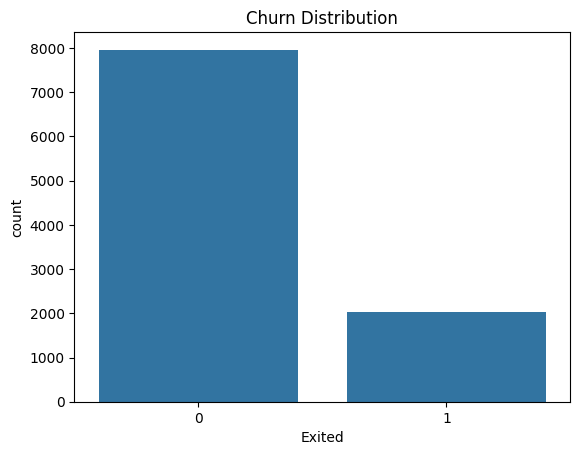

In [7]:
# Churn Distribution
sns.countplot(x="Exited", data=df)
plt.title('Churn Distribution')
plt.show()

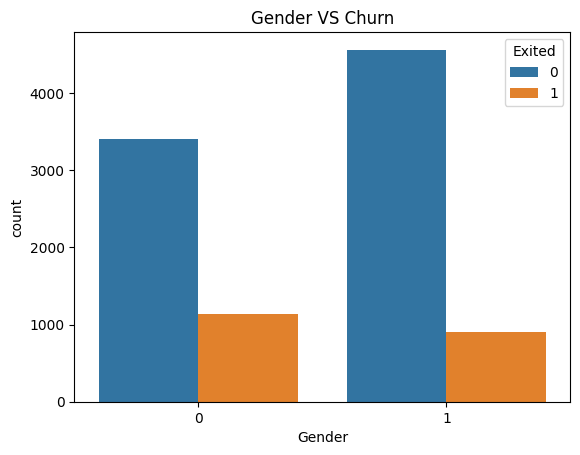

In [8]:
# Step 9: Gender Vs Churn
sns.countplot(x="Gender", hue="Exited", data=df)
plt.title("Gender VS Churn")
plt.show()

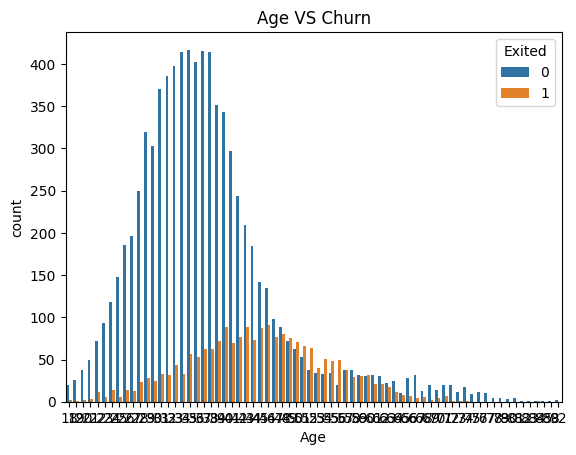

In [9]:
sns.countplot(x='Age', hue='Exited', data=df)
plt.title("Age VS Churn")
plt.show()

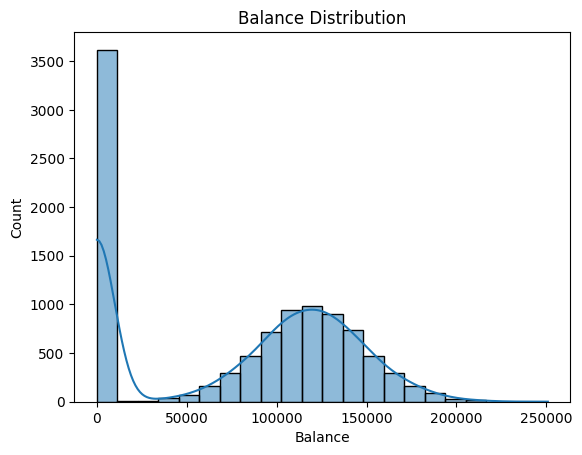

In [10]:
# Step 10: Boxplot
sns.histplot(df['Balance'], kde=True)
plt.title("Balance Distribution")
plt.show()

In [21]:
# Step 10: Prepare Dataset
X= df.drop(['Exited'], axis=1)
Y= df['Exited']

In [22]:
#  Train Data with train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size=.2, random_state=42)

In [24]:
# Step 11: Apply Logistic Regression
lr= LogisticRegression(max_iter=1000) # Increased max_iter to 1000
lr.fit(X_train, Y_train)
y_pred= lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with original column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")


Features scaled successfully!


In [26]:
lr_scaled = LogisticRegression(max_iter=1000)
lr_scaled.fit(X_train_scaled, Y_train)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

print("Logistic Regression model trained on scaled data.")

Logistic Regression model trained on scaled data.


In [27]:
accuracy_scaled = accuracy_score(Y_test, y_pred_scaled)
conf_matrix_scaled = confusion_matrix(Y_test, y_pred_scaled)

print(f"Accuracy with scaled features: {accuracy_scaled:.4f}")
print("Confusion Matrix with scaled features:\n", conf_matrix_scaled)

Accuracy with scaled features: 0.8110
Confusion Matrix with scaled features:
 [[1543   64]
 [ 314   79]]


In [28]:
# Step 12: Apply Decision Tree
dt= DecisionTreeClassifier()
dt.fit(X_train, Y_train)
dt_pred= dt.predict(X_test)

In [33]:
print("LR Accuracy:", accuracy_score(Y_test, y_pred))
print("DT Accuracy:", accuracy_score(Y_test, dt_pred))

LR Accuracy: 0.814
DT Accuracy: 0.775


In [36]:
cm=confusion_matrix(Y_test, y_pred)
print(cm)

[[1547   60]
 [ 312   81]]


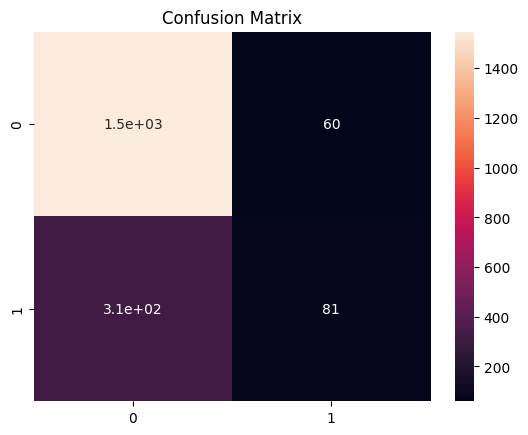

In [37]:
# Step 13: Heatmap
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()

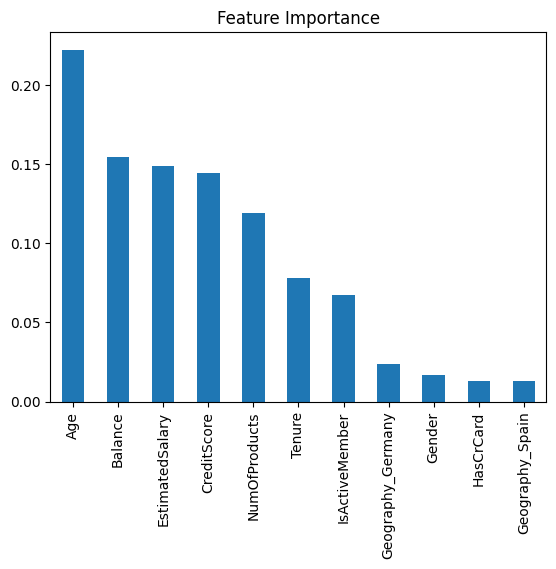

In [38]:
# Step 14: Feature Importance
feature_importance = pd.Series(dt.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Importance')
plt.show()